# Model Comparison

The project already has a K-Means baseline with `SELECTED_K = 5`. This notebook checks whether Gaussian Mixture Models provide a better alternative.

The comparison uses the same selected model features as the baseline. The final model decision should consider clustering metrics, cluster balance, and business interpretability. This notebook does not replace the existing baseline yet.

## Imports and Setup

The notebook uses direct string paths and the existing reusable clustering helpers.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

sys.path.append(os.getcwd())

from src.clustering import (
    evaluate_clustering_solution,
    fit_gmm,
    fit_kmeans,
    get_cluster_summary,
    sample_clustering_data,
    split_customer_features,
    validate_clustering_input,
)

os.makedirs("outputs/clustering", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

## Load and Validate Data

The model comparison uses `selected_model_features.csv`, which is already scaled, encoded, and ready for clustering.

In [2]:
df = pd.read_csv("data/processed/selected_model_features.csv")
validate_clustering_input(df)

customer_ids, X = split_customer_features(df)

row_count = len(df)
unique_customer_count = df["customer_id"].nunique()
duplicated_customer_count = df["customer_id"].duplicated().sum()
missing_value_count = df.isna().sum().sum()
non_numeric_columns = X.select_dtypes(exclude="number").columns.tolist()

print(f"Rows loaded: {row_count:,}")
print(f"Unique customer_id values: {unique_customer_count:,}")
print(f"Duplicated customer_id count: {duplicated_customer_count:,}")
print(f"Total missing values: {missing_value_count:,}")
print(f"Model feature columns: {X.shape[1]}")
print(f"All model features numeric: {len(non_numeric_columns) == 0}")

if row_count != 33038:
    raise ValueError(f"Expected 33,038 rows, found {row_count:,}.")

print("Input validation passed.")

Rows loaded: 33,038
Unique customer_id values: 33,038
Duplicated customer_id count: 0
Total missing values: 0
Model feature columns: 25
All model features numeric: True
Input validation passed.


## Fit K-Means Baseline

The existing baseline uses K-Means with `k=5`. It is included here as the reference model.

In [3]:
comparison_rows = []
balance_rows = []

print("Fitting KMeans_k5")
kmeans, kmeans_labels = fit_kmeans(X, n_clusters=5, random_state=42, n_init=50)

kmeans_metrics = evaluate_clustering_solution(
    X,
    kmeans_labels,
    model_name="KMeans_k5",
    algorithm="KMeans",
    n_clusters=5,
    extra_metrics={
        "inertia": kmeans.inertia_,
        "aic": None,
        "bic": None,
        "avg_max_probability": None,
    },
)
comparison_rows.append(kmeans_metrics)

kmeans_balance = get_cluster_summary(kmeans_labels)
kmeans_balance["model"] = "KMeans_k5"
balance_rows.append(kmeans_balance[["model", "cluster", "count", "percentage"]])

print("K-Means baseline fitted.")

Fitting KMeans_k5
K-Means baseline fitted.


## Fit Gaussian Mixture Models

The GMM alternatives use diagonal covariance and test 4, 5, and 6 components.

In [4]:
for n_components in [4, 5, 6]:
    model_name = f"GMM_diag_k{n_components}"
    print(f"Fitting {model_name}")

    gmm, gmm_labels = fit_gmm(
        X,
        n_components=n_components,
        covariance_type="diag",
        random_state=42,
    )
    probabilities = gmm.predict_proba(X)

    gmm_metrics = evaluate_clustering_solution(
        X,
        gmm_labels,
        model_name=model_name,
        algorithm="GMM_diag",
        n_clusters=n_components,
        extra_metrics={
            "inertia": None,
            "aic": gmm.aic(X),
            "bic": gmm.bic(X),
            "avg_max_probability": probabilities.max(axis=1).mean(),
        },
    )
    comparison_rows.append(gmm_metrics)

    gmm_balance = get_cluster_summary(gmm_labels)
    gmm_balance["model"] = model_name
    balance_rows.append(gmm_balance[["model", "cluster", "count", "percentage"]])

print("GMM models fitted.")

Fitting GMM_diag_k4
Fitting GMM_diag_k5
Fitting GMM_diag_k6
GMM models fitted.


## Save Comparison Metrics

The comparison table keeps K-Means inertia and GMM likelihood-based metrics in the same output, using missing values where a metric does not apply.

In [5]:
comparison = pd.DataFrame(comparison_rows)
comparison = comparison[[
    "model",
    "algorithm",
    "n_clusters",
    "silhouette_score",
    "calinski_harabasz_score",
    "davies_bouldin_score",
    "min_cluster_size",
    "max_cluster_size",
    "min_cluster_percentage",
    "max_cluster_percentage",
    "inertia",
    "aic",
    "bic",
    "avg_max_probability",
]]

comparison.to_csv("outputs/clustering/model_comparison_metrics.csv", index=False)

print("Saved metrics to outputs/clustering/model_comparison_metrics.csv")
comparison

Saved metrics to outputs/clustering/model_comparison_metrics.csv


,model,algorithm,n_clusters,silhouette_score,calinski_harabasz_score,davies_bouldin_score,min_cluster_size,max_cluster_size,min_cluster_percentage,max_cluster_percentage,inertia,aic,bic,avg_max_probability
0,KMeans_k5,KMeans,5,0.135222,3650.808841,2.108630,2234,10841,6.761911,32.813730,478598.468556,NaN,NaN,NaN
1,GMM_diag_k4,GMM_diag,4,0.023831,1709.353031,3.003186,1791,17502,5.421030,52.975362,NaN,840349.724900,842056.023880,0.985930
2,GMM_diag_k5,GMM_diag,5,0.025050,1423.619715,3.601899,803,17430,2.430535,52.757431,NaN,708147.193856,710282.168934,0.990380
3,GMM_diag_k6,GMM_diag,6,-0.021981,1362.801618,3.081184,788,17436,2.385132,52.775592,NaN,780147.230901,782710.882077,0.978671


## Save Cluster Balance Table

This table stores cluster size and percentage for every tested model.

In [6]:
cluster_balance = pd.concat(balance_rows, ignore_index=True)
cluster_balance.to_csv("outputs/clustering/model_comparison_cluster_balance.csv", index=False)

print("Saved cluster balance to outputs/clustering/model_comparison_cluster_balance.csv")
cluster_balance

Saved cluster balance to outputs/clustering/model_comparison_cluster_balance.csv


,model,cluster,count,percentage
0,KMeans_k5,0,2234,6.761911
1,KMeans_k5,1,10841,32.813730
2,KMeans_k5,2,6687,20.240329
3,KMeans_k5,3,9889,29.932199
4,KMeans_k5,4,3387,10.251831
5,GMM_diag_k4,0,1791,5.421030
6,GMM_diag_k4,1,5756,17.422362
7,GMM_diag_k4,2,17502,52.975362
8,GMM_diag_k4,3,7989,24.181246
9,GMM_diag_k5,0,803,2.430535


## Comparison Plots

The plots compare separation and basic cluster balance across the tested models.

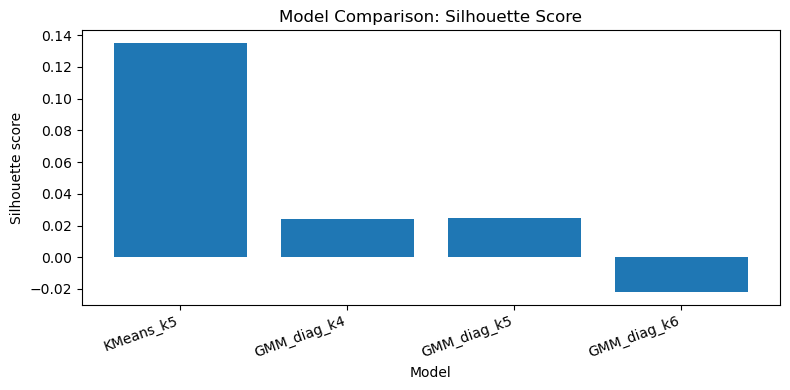

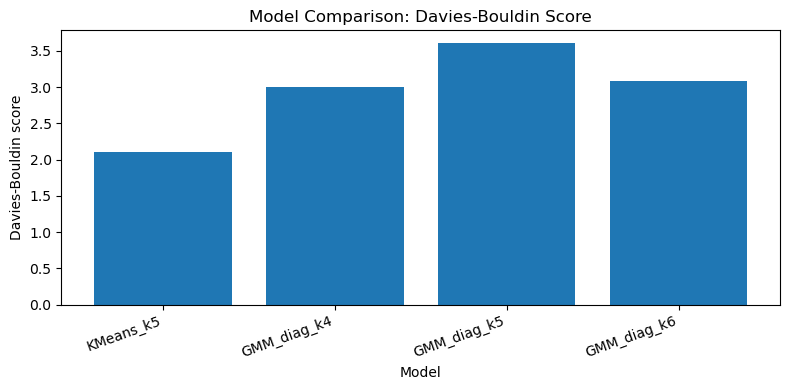

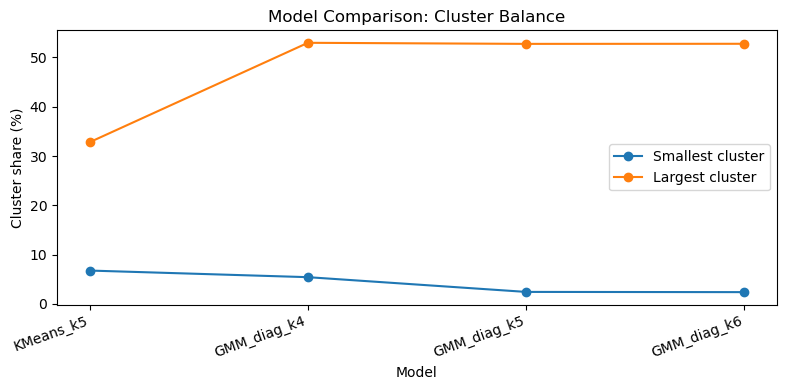

In [7]:
plt.figure(figsize=(8, 4))
plt.bar(comparison["model"], comparison["silhouette_score"])
plt.xlabel("Model")
plt.ylabel("Silhouette score")
plt.title("Model Comparison: Silhouette Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("outputs/figures/model_comparison_silhouette.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(comparison["model"], comparison["davies_bouldin_score"])
plt.xlabel("Model")
plt.ylabel("Davies-Bouldin score")
plt.title("Model Comparison: Davies-Bouldin Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("outputs/figures/model_comparison_davies_bouldin.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(comparison["model"], comparison["min_cluster_percentage"], marker="o", label="Smallest cluster")
plt.plot(comparison["model"], comparison["max_cluster_percentage"], marker="o", label="Largest cluster")
plt.xlabel("Model")
plt.ylabel("Cluster share (%)")
plt.title("Model Comparison: Cluster Balance")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/model_comparison_cluster_balance.png", dpi=150)
plt.show()

## Short Interpretation

- `KMeans_k5` has the best silhouette score in this comparison, at about 0.135.
- `KMeans_k5` also has the best Davies-Bouldin score, at about 2.109. Lower Davies-Bouldin values are better.
- The GMM models have weaker cluster balance. Each GMM creates one very large cluster of about 53% of customers, and `GMM_diag_k5` and `GMM_diag_k6` also create very small clusters around 2.4% of customers.
- Among the GMM models, `GMM_diag_k5` has the lowest AIC and BIC, but it does not improve the clustering separation metrics or balance compared with K-Means.
- Based on this first comparison, GMM does not clearly improve over the current K-Means baseline. K-Means with `k=5` remains a reasonable baseline candidate, but the final decision should still use cluster interpretation and business usefulness.

## Complementary Models: Agglomerative Clustering and DBSCAN

This section adds a sampled comparison using the same selected model features. Agglomerative Clustering provides a hierarchical reference point, while DBSCAN is used as an outlier diagnostic rather than a primary segmentation candidate. All models in this section use the same reproducible sample of 5,000 customers with `random_state = 42`.

In [8]:
sample_size = 5000
random_state = 42

X_sample = sample_clustering_data(
    X,
    sample_size=sample_size,
    random_state=random_state,
)

complementary_rows = []
complementary_balance_rows = []

print(f"Sampled rows: {len(X_sample):,}")

model_name = "KMeans_k5_sample"
print(f"Fitting {model_name}")

kmeans_sample, kmeans_sample_labels = fit_kmeans(
    X_sample,
    n_clusters=5,
    random_state=random_state,
    n_init=50,
)
kmeans_sample_summary = get_cluster_summary(kmeans_sample_labels)

kmeans_sample_metrics = evaluate_clustering_solution(
    X_sample,
    kmeans_sample_labels,
    model_name=model_name,
    algorithm="KMeans",
    n_clusters=5,
    extra_metrics={
        "sample_size": len(X_sample),
        "eps": None,
        "min_samples": None,
        "number_of_clusters_excluding_noise": len(kmeans_sample_summary),
        "noise_count": 0,
        "noise_percentage": 0,
        "largest_non_noise_cluster_percentage": kmeans_sample_summary["percentage"].max(),
        "inertia": kmeans_sample.inertia_,
    },
)
complementary_rows.append(kmeans_sample_metrics)

kmeans_sample_balance = kmeans_sample_summary.copy()
kmeans_sample_balance["model"] = model_name
kmeans_sample_balance["algorithm"] = "KMeans"
kmeans_sample_balance["is_noise"] = False
complementary_balance_rows.append(
    kmeans_sample_balance[["model", "algorithm", "cluster", "count", "percentage", "is_noise"]]
)

print("Sample K-Means benchmark fitted.")

Sampled rows: 5,000
Fitting KMeans_k5_sample
Sample K-Means benchmark fitted.


### Agglomerative Clustering

Ward-linkage Agglomerative Clustering is tested with 4, 5, and 6 clusters on the same sampled rows. These runs are compared against the sampled K-Means benchmark rather than the full-data baseline, because the hierarchical fit is more expensive.

In [9]:
for n_clusters in [4, 5, 6]:
    model_name = f"Agglomerative_ward_k{n_clusters}_sample"
    print(f"Fitting {model_name}")

    agglomerative = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    agglomerative_labels = agglomerative.fit_predict(X_sample)
    agglomerative_summary = get_cluster_summary(agglomerative_labels)

    agglomerative_metrics = evaluate_clustering_solution(
        X_sample,
        agglomerative_labels,
        model_name=model_name,
        algorithm="Agglomerative_ward",
        n_clusters=n_clusters,
        extra_metrics={
            "sample_size": len(X_sample),
            "eps": None,
            "min_samples": None,
            "number_of_clusters_excluding_noise": n_clusters,
            "noise_count": 0,
            "noise_percentage": 0,
            "largest_non_noise_cluster_percentage": agglomerative_summary["percentage"].max(),
            "inertia": None,
        },
    )
    complementary_rows.append(agglomerative_metrics)

    agglomerative_balance = agglomerative_summary.copy()
    agglomerative_balance["model"] = model_name
    agglomerative_balance["algorithm"] = "Agglomerative_ward"
    agglomerative_balance["is_noise"] = False
    complementary_balance_rows.append(
        agglomerative_balance[["model", "algorithm", "cluster", "count", "percentage", "is_noise"]]
    )

print("Agglomerative models fitted.")

Fitting Agglomerative_ward_k4_sample
Fitting Agglomerative_ward_k5_sample
Fitting Agglomerative_ward_k6_sample
Agglomerative models fitted.


### DBSCAN Diagnostic

DBSCAN is tested on the same sample to check whether density-based structure or outliers are prominent. Noise label `-1` is kept in the balance table, while cluster-size metrics and separation metrics use non-noise clusters only. Separation metrics are only calculated when there are at least two non-noise clusters and enough non-noise points.

In [10]:
for eps in [2, 3, 4, 5]:
    for min_samples in [10, 20]:
        model_name = f"DBSCAN_eps{eps}_min{min_samples}_sample"
        print(f"Fitting {model_name}")

        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X_sample)
        dbscan_summary = get_cluster_summary(dbscan_labels)
        non_noise_summary = dbscan_summary[dbscan_summary["cluster"] != -1]
        noise_row = dbscan_summary[dbscan_summary["cluster"] == -1]

        noise_count = int(noise_row["count"].iloc[0]) if len(noise_row) else 0
        noise_percentage = noise_count / len(dbscan_labels) * 100
        non_noise_mask = dbscan_labels != -1
        non_noise_count = int(non_noise_mask.sum())
        non_noise_cluster_count = len(non_noise_summary)

        dbscan_metrics = {
            "model": model_name,
            "algorithm": "DBSCAN",
            "n_clusters": None,
            "sample_size": len(X_sample),
            "eps": eps,
            "min_samples": min_samples,
            "number_of_clusters_excluding_noise": non_noise_cluster_count,
            "noise_count": noise_count,
            "noise_percentage": noise_percentage,
            "largest_non_noise_cluster_percentage": None,
            "silhouette_score": None,
            "calinski_harabasz_score": None,
            "davies_bouldin_score": None,
            "min_cluster_size": None,
            "max_cluster_size": None,
            "min_cluster_percentage": None,
            "max_cluster_percentage": None,
            "inertia": None,
        }

        if non_noise_cluster_count > 0:
            dbscan_metrics.update({
                "largest_non_noise_cluster_percentage": non_noise_summary["percentage"].max(),
                "min_cluster_size": int(non_noise_summary["count"].min()),
                "max_cluster_size": int(non_noise_summary["count"].max()),
                "min_cluster_percentage": non_noise_summary["percentage"].min(),
                "max_cluster_percentage": non_noise_summary["percentage"].max(),
            })

        if non_noise_cluster_count >= 2 and non_noise_count > non_noise_cluster_count:
            X_non_noise = X_sample[non_noise_mask]
            labels_non_noise = dbscan_labels[non_noise_mask]
            metric_sample_size = min(3000, non_noise_count)

            dbscan_metrics.update({
                "silhouette_score": silhouette_score(
                    X_non_noise,
                    labels_non_noise,
                    sample_size=metric_sample_size,
                    random_state=random_state,
                ),
                "calinski_harabasz_score": calinski_harabasz_score(X_non_noise, labels_non_noise),
                "davies_bouldin_score": davies_bouldin_score(X_non_noise, labels_non_noise),
            })

        complementary_rows.append(dbscan_metrics)

        dbscan_balance = dbscan_summary.copy()
        dbscan_balance["model"] = model_name
        dbscan_balance["algorithm"] = "DBSCAN"
        dbscan_balance["is_noise"] = dbscan_balance["cluster"] == -1
        complementary_balance_rows.append(
            dbscan_balance[["model", "algorithm", "cluster", "count", "percentage", "is_noise"]]
        )

print("DBSCAN diagnostics fitted.")

Fitting DBSCAN_eps2_min10_sample
Fitting DBSCAN_eps2_min20_sample
Fitting DBSCAN_eps3_min10_sample
Fitting DBSCAN_eps3_min20_sample
Fitting DBSCAN_eps4_min10_sample
Fitting DBSCAN_eps4_min20_sample
Fitting DBSCAN_eps5_min10_sample
Fitting DBSCAN_eps5_min20_sample
DBSCAN diagnostics fitted.


### Save Complementary Outputs

The complementary output files are separate from the existing K-Means and GMM comparison outputs.

In [11]:
complementary_metrics = pd.DataFrame(complementary_rows)
complementary_metrics = complementary_metrics[[
    "model",
    "algorithm",
    "sample_size",
    "n_clusters",
    "eps",
    "min_samples",
    "number_of_clusters_excluding_noise",
    "noise_count",
    "noise_percentage",
    "largest_non_noise_cluster_percentage",
    "silhouette_score",
    "calinski_harabasz_score",
    "davies_bouldin_score",
    "min_cluster_size",
    "max_cluster_size",
    "min_cluster_percentage",
    "max_cluster_percentage",
    "inertia",
]]

complementary_cluster_balance = pd.concat(complementary_balance_rows, ignore_index=True)
complementary_cluster_balance = complementary_cluster_balance[[
    "model",
    "algorithm",
    "cluster",
    "count",
    "percentage",
    "is_noise",
]]

complementary_metrics.to_csv(
    "outputs/clustering/model_comparison_complementary_metrics.csv",
    index=False,
)
complementary_cluster_balance.to_csv(
    "outputs/clustering/model_comparison_complementary_cluster_balance.csv",
    index=False,
)

print("Saved metrics to outputs/clustering/model_comparison_complementary_metrics.csv")
print("Saved cluster balance to outputs/clustering/model_comparison_complementary_cluster_balance.csv")

complementary_metrics

Saved metrics to outputs/clustering/model_comparison_complementary_metrics.csv
Saved cluster balance to outputs/clustering/model_comparison_complementary_cluster_balance.csv


,model,algorithm,sample_size,n_clusters,eps,min_samples,number_of_clusters_excluding_noise,noise_count,noise_percentage,largest_non_noise_cluster_percentage,silhouette_score,calinski_harabasz_score,davies_bouldin_score,min_cluster_size,max_cluster_size,min_cluster_percentage,max_cluster_percentage,inertia
0,KMeans_k5_sample,KMeans,5000,5.0,NaN,NaN,5,0,0.00,33.04,0.135365,554.060494,2.101751,365,1652,7.30,33.04,73270.84712
1,Agglomerative_ward_k4_sample,Agglomerative_ward,5000,4.0,NaN,NaN,4,0,0.00,36.56,0.102386,503.373397,2.521294,751,1828,15.02,36.56,NaN
2,Agglomerative_ward_k5_sample,Agglomerative_ward,5000,5.0,NaN,NaN,5,0,0.00,36.56,0.116842,474.776532,2.272436,197,1828,3.94,36.56,NaN
3,Agglomerative_ward_k6_sample,Agglomerative_ward,5000,6.0,NaN,NaN,6,0,0.00,36.56,0.100171,443.995858,2.213907,197,1828,3.94,36.56,NaN
4,DBSCAN_eps2_min10_sample,DBSCAN,5000,NaN,2.0,10.0,10,4295,85.90,3.90,0.135452,106.448260,1.618014,4,195,0.08,3.90,NaN
5,DBSCAN_eps2_min20_sample,DBSCAN,5000,NaN,2.0,20.0,5,4655,93.10,3.26,0.284622,120.414420,1.687630,13,163,0.26,3.26,NaN
6,DBSCAN_eps3_min10_sample,DBSCAN,5000,NaN,3.0,10.0,1,808,16.16,83.84,NaN,NaN,NaN,4192,4192,83.84,83.84,NaN
7,DBSCAN_eps3_min20_sample,DBSCAN,5000,NaN,3.0,20.0,2,968,19.36,71.26,0.227668,596.393157,1.563436,469,3563,9.38,71.26,NaN
8,DBSCAN_eps4_min10_sample,DBSCAN,5000,NaN,4.0,10.0,1,190,3.80,96.20,NaN,NaN,NaN,4810,4810,96.20,96.20,NaN
9,DBSCAN_eps4_min20_sample,DBSCAN,5000,NaN,4.0,20.0,1,216,4.32,95.68,NaN,NaN,NaN,4784,4784,95.68,95.68,NaN


### Complementary Plots

These simple plots focus on the sampled agglomerative comparison and DBSCAN diagnostic behavior.

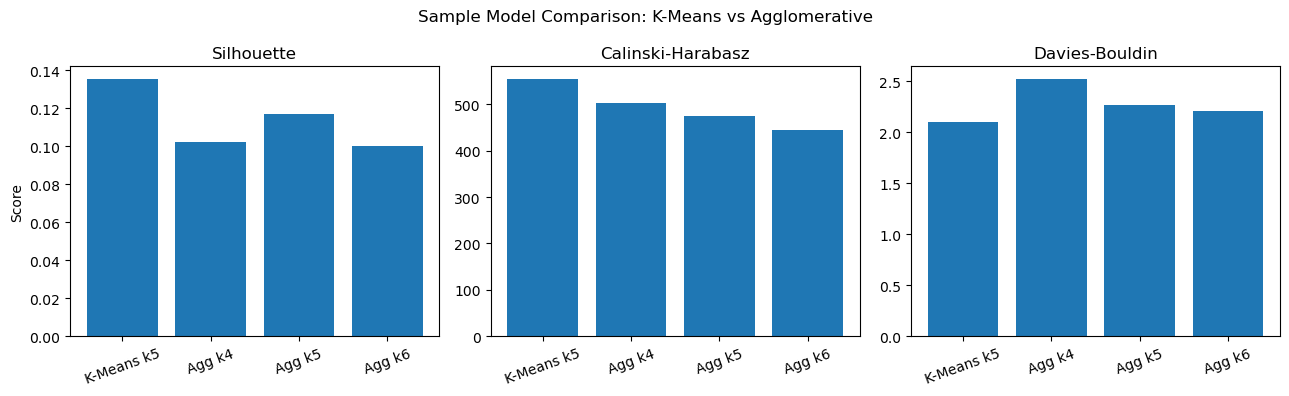

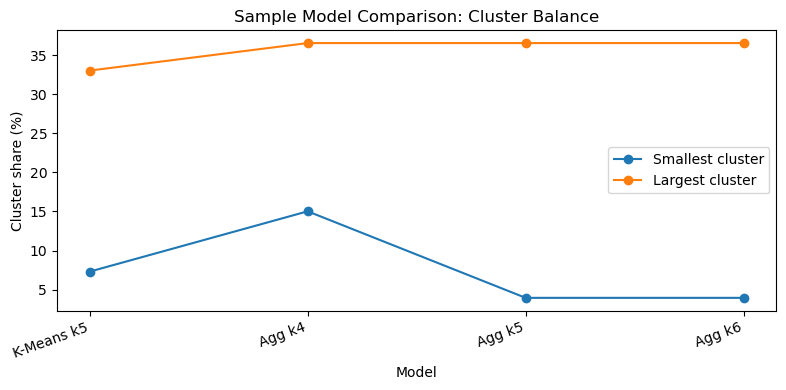

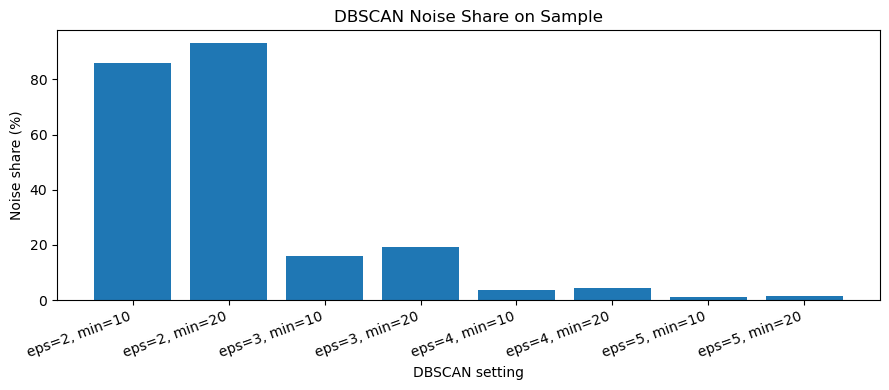

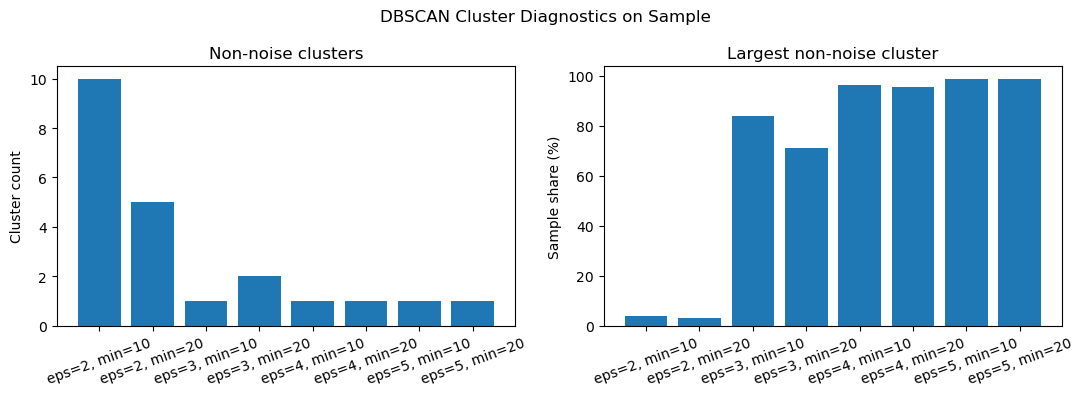

In [12]:
agglomerative_plot = complementary_metrics[
    complementary_metrics["algorithm"].isin(["KMeans", "Agglomerative_ward"])
].copy()
agglomerative_plot["plot_label"] = agglomerative_plot["model"].replace({
    "KMeans_k5_sample": "K-Means k5",
    "Agglomerative_ward_k4_sample": "Agg k4",
    "Agglomerative_ward_k5_sample": "Agg k5",
    "Agglomerative_ward_k6_sample": "Agg k6",
})

dbscan_plot = complementary_metrics[complementary_metrics["algorithm"] == "DBSCAN"].copy()
dbscan_plot["setting"] = dbscan_plot.apply(
    lambda row: f"eps={int(row['eps'])}, min={int(row['min_samples'])}",
    axis=1,
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].bar(agglomerative_plot["plot_label"], agglomerative_plot["silhouette_score"])
axes[0].set_title("Silhouette")
axes[0].set_ylabel("Score")
axes[1].bar(agglomerative_plot["plot_label"], agglomerative_plot["calinski_harabasz_score"])
axes[1].set_title("Calinski-Harabasz")
axes[2].bar(agglomerative_plot["plot_label"], agglomerative_plot["davies_bouldin_score"])
axes[2].set_title("Davies-Bouldin")
for axis in axes:
    axis.tick_params(axis="x", rotation=20)
plt.suptitle("Sample Model Comparison: K-Means vs Agglomerative")
plt.tight_layout()
plt.savefig("outputs/figures/model_comparison_agglomerative_metrics.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(
    agglomerative_plot["plot_label"],
    agglomerative_plot["min_cluster_percentage"],
    marker="o",
    label="Smallest cluster",
)
plt.plot(
    agglomerative_plot["plot_label"],
    agglomerative_plot["max_cluster_percentage"],
    marker="o",
    label="Largest cluster",
)
plt.xlabel("Model")
plt.ylabel("Cluster share (%)")
plt.title("Sample Model Comparison: Cluster Balance")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/model_comparison_agglomerative_balance.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(dbscan_plot["setting"], dbscan_plot["noise_percentage"])
plt.xlabel("DBSCAN setting")
plt.ylabel("Noise share (%)")
plt.title("DBSCAN Noise Share on Sample")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("outputs/figures/model_comparison_dbscan_noise.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(dbscan_plot["setting"], dbscan_plot["number_of_clusters_excluding_noise"])
axes[0].set_title("Non-noise clusters")
axes[0].set_ylabel("Cluster count")
axes[1].bar(dbscan_plot["setting"], dbscan_plot["largest_non_noise_cluster_percentage"])
axes[1].set_title("Largest non-noise cluster")
axes[1].set_ylabel("Sample share (%)")
for axis in axes:
    axis.tick_params(axis="x", rotation=20)
plt.suptitle("DBSCAN Cluster Diagnostics on Sample")
plt.tight_layout()
plt.savefig("outputs/figures/model_comparison_dbscan_clusters.png", dpi=150)
plt.show()

### Complementary Interpretation

- On the 5,000-customer sample, `KMeans_k5_sample` remains the strongest sampled reference among the centroid and hierarchical models. Its silhouette score is about 0.135, compared with about 0.117 for the best agglomerative result, `Agglomerative_ward_k5_sample`.
- Agglomerative Clustering does not give clearly better evidence than K-Means. The 5-cluster agglomerative model has the best agglomerative silhouette score, while the 6-cluster version has the best agglomerative Davies-Bouldin score. None of the agglomerative options improves the overall evidence across silhouette, Calinski-Harabasz, Davies-Bouldin, and balance.
- The agglomerative results mildly support the idea that a 5-cluster structure is plausible, because `Agglomerative_ward_k5_sample` is the best hierarchical option by silhouette. They do not contradict K-Means k=5, but they also do not make the case stronger than the K-Means baseline.
- DBSCAN is more useful here as an outlier diagnostic. With `eps=2`, it labels most sampled customers as noise, from about 86% to 93%. With larger `eps` values, it usually collapses into one dominant non-noise cluster, often covering more than 95% of the sample.
- Because DBSCAN either produces very high noise rates or one dominant cluster under this grid, it is not suitable as the main segmentation model for this project. It does suggest that some customers sit outside dense neighborhoods, but it does not provide a stable multi-segment solution.
- Taken together, this complementary check leaves K-Means k=5 as the strongest practical candidate so far. That should still be treated as provisional until the final model choice is checked against segment profiles and business usefulness.